# Tutorial — your first simulated rollout (about one minute of compute)

> **⚠ ALL DATA IS SYNTHETIC.** Generated organizations, stipulated thresholds,
> uncalibrated dynamics — a reasoning instrument, not a forecast
> ([`docs/limitations.md`](../docs/limitations.md)).

This is the gentle on-ramp to **adoption-sim**: generate a synthetic organization
(the headline experiment's own scale — it only takes seconds),
run one complex-contagion rollout through it, see *why* the non-adopters didn't
adopt, and compare two seeding strategies. The real experiments live in notebooks
01–03; the model math is in [`docs/model.md`](../docs/model.md) and every modeling
choice (with alternatives) in [`docs/decisions.md`](../docs/decisions.md)
(**D1–D17 RATIFIED 2026-06-10**).

Setup: either `pip install -r requirements-dev.txt -c constraints.txt` from the
repo root (the README path), or `pip install -e .` for the engine alone — this
notebook detects both.

In [1]:
import sys, pathlib, time
HERE = pathlib.Path.cwd().resolve()
REPO = HERE if (HERE / "core").exists() else HERE.parent
T0 = time.time()

try:                       # installed package (pip install -e .)
    import adoption_sim as sim
except ImportError:        # repo-local fallback — no install needed
    sys.path.insert(0, str(REPO))
    import core as sim

sys.path.insert(0, str(REPO / "experiments"))
import numpy as np
import matplotlib.pyplot as plt
import plotting            # repo plotting helpers — synthetic-data stamp included

print(f"adoption-sim {sim.__version__} · imported as {sim.__name__!r}")

adoption-sim 0.1.0 · imported as 'core'


## 1. Generate an organization

Two layers (decision D10): the **org chart** (CEO → 8 department heads → ~250 teams)
and the **informal influence network** — dense inside teams, locally concentrated
between neighboring "sister teams", deliberately sparse across departments
(`silo_strength`). Adoption will only travel on the informal layer.

We load the **frozen headline scenario** (D16) straight from its TOML — scenario
files are the unit of reproducibility here, and typos in them fail loudly.

In [2]:
from core.scenario import load_scenario, org_kwargs, build_sim_params, set_path
SC = load_scenario(REPO / "experiments" / "scenarios" / "headline.toml")
org = sim.generate_org(**org_kwargs(SC), seed=7)
compiled = org.compile()
deg = compiled.degrees()
print(f"{compiled.n} agents · {org.informal.number_of_edges()} informal ties · "
      f"mean degree {deg.mean():.1f} · {compiled.n_teams - 1} line teams in 8 departments")
print(f"roles: {int((compiled.role == 1).sum())} line managers, "
      f"{int((compiled.role == 2).sum())} leadership, rest ICs")

2000 agents · 14122 informal ties · mean degree 14.1 · 249 line teams in 8 departments
roles: 249 line managers, 9 leadership, rest ICs


## 2. One rollout, three gates

Each agent adopts only when **all three** hold (D4–D6):

- **ready** — the credibility-weighted share of their contacts who already adopted
  reaches their personal threshold θᵢ ~ Beta(μ=0.30, κ=20), plus a 2.5% mass of
  zero-threshold *innovators* (D1/D2) — κ=20 selects the headline regime (D1 is
  dual-regime; the engine default κ=8 is the neutral parameterization);
- **willing** — an 85% coin flipped once per person (D5);
- **able** — practical access, 100% in this scenario (D6).

We seed **whole pilot teams** worth 5% of the organization (the `cluster` strategy)
and watch the cascade. Every run is exactly reproducible from its seeds.

seeded 100 agents in teams [149, 76, 127, 188, 101, 21, 75, 8, 185, 244, 104, 6, 214]
final adoption: 32.4% (converged at step 32)
why the rest didn't adopt: {'adopted': 648, 'not_able': 0, 'not_willing': 286, 'not_ready': 1066, 'relapsed': 0}


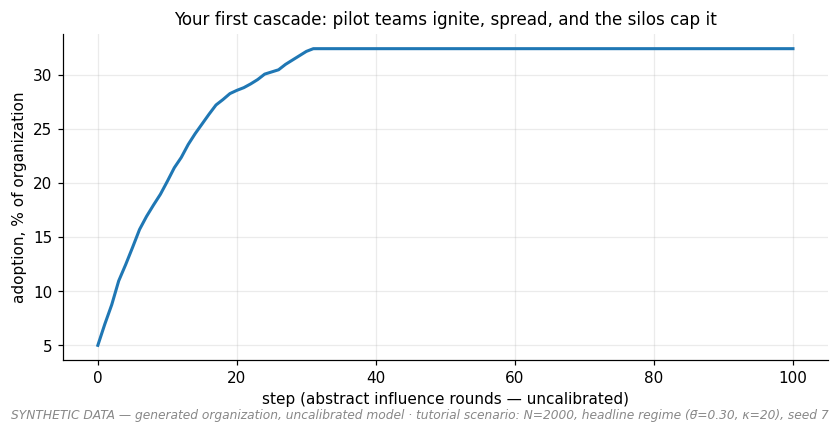

In [3]:
seeding = sim.make_seeding("cluster", compiled, budget=SC["seeding"]["budget"], rng=7)
params = build_sim_params(SC)   # headline regime: θ̄=0.30, κ=20 (D1/D16)
result = sim.run_simulation(compiled, params, seeding, rng=7)

print(f"seeded {seeding.initial_adopters.size} agents in teams {seeding.meta['teams_seeded']}")
print(f"final adoption: {result.final_rate:.1%} (converged at step {result.steps_to_fixed_point})")
print("why the rest didn't adopt:", result.attribution_counts())

fig, ax = plotting.fig_with_stamp(figsize=(7.5, 3.8),
    note="tutorial scenario: N=2000, headline regime (θ̄=0.30, κ=20), seed 7")
ax.plot(100 * result.curve, lw=2, color=plotting.STRATEGY_COLORS["cluster"])
ax.set_xlabel("step (abstract influence rounds — uncalibrated)")
ax.set_ylabel("adoption, % of organization")
ax.set_title("Your first cascade: pilot teams ignite, spread, and the silos cap it", fontsize=11)
plt.show()

The attribution counts are the model's diagnostic payoff: every non-adopter is
**exactly one** of *not ready* (never saw enough credible adoption — the structural
failure a better seeding geometry attacks), *not willing* (the 15% disposition
lottery), *not able* (capacity; none here), or *relapsed* (decay is off here, D7).

## 3. Compare strategies properly (replicates, not anecdotes)

Single runs are anecdotes; the engine's sweep machinery runs replicated comparisons
with airtight seed bookkeeping (D14: a fresh organization per replicate). Here:
**broadcast** (0 seeds — it buys awareness, not adopters, D8/D9) vs **random**
vs **cluster**, 8 replicates each, on fresh 2000-agent organizations.

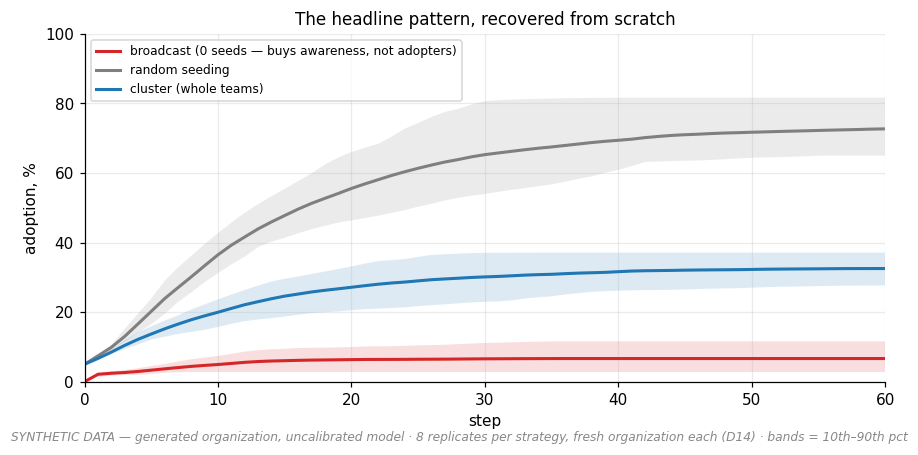

broadcast    6.6% ± 4.0%
random      72.8% ± 7.1%
cluster     32.7% ± 3.6%


In [4]:
from core.sweep import expand_jobs, sweep  # same modules under either import name

sc = set_path(SC, "run.replicates", 8)   # tutorial-sized; experiment 1 uses 50
sc = set_path(sc, "run.master_seed", 7)

rows = sweep(expand_jobs(sc, {"seeding.strategy": ["broadcast", "random", "cluster"]}))
import json
fig, ax = plotting.fig_with_stamp(figsize=(8, 4),
    note="8 replicates per strategy, fresh organization each (D14) · bands = 10th–90th pct")
for strat in ("broadcast", "random", "cluster"):
    stack = np.array([json.loads(r["curve"]) for r in rows if r["strategy"] == strat])
    mean = stack.mean(axis=0)
    ax.plot(100 * mean, lw=2, color=plotting.STRATEGY_COLORS[strat],
            label=plotting.STRATEGY_LABELS[strat])
    ax.fill_between(np.arange(stack.shape[1]),
                    100 * np.percentile(stack, 10, axis=0),
                    100 * np.percentile(stack, 90, axis=0),
                    color=plotting.STRATEGY_COLORS[strat], alpha=0.15, linewidth=0)
ax.set_xlim(0, 60); ax.set_ylim(0, 100)
ax.set_xlabel("step"); ax.set_ylabel("adoption, %")
ax.set_title("The headline pattern, recovered from scratch", fontsize=11)
ax.legend(fontsize=8)
plt.show()
for strat in ("broadcast", "random", "cluster"):
    finals = [r["final_rate"] for r in rows if r["strategy"] == strat]
    print(f"{strat:10s} {np.mean(finals):6.1%} ± {np.std(finals):.1%}")

Yes — **random beats cluster on reach**. That is not a bug;
it is this project's headline *negative result* (D16), reported rather than hidden:
in organizations made of dense small teams, every scattered seed is already embedded
in a cluster. Cluster seeding's real case is **retention under decay** (experiment 1
§9) — and no, making usage more visible doesn't change the ordering either
(experiment 3, with a proof).

## 4. Where to go next

- **Experiment 1** ([`01_broadcast_vs_cluster.ipynb`](01_broadcast_vs_cluster.ipynb)) —
  the dual-regime headline, innovator and campaign-duration sweeps, dead pockets,
  decay, pivot nodes.
- **Experiment 2** ([`02_sanity_checks.ipynb`](02_sanity_checks.ipynb)) — does the
  engine reproduce Granovetter, Centola–Macy, Watts? (Plus the tornado.)
- **Experiment 3** ([`03_observability.ipynb`](03_observability.ipynb)) — invisible
  usage, the θ/v theorem, observable pilots.
- **The demo** — `streamlit run demo/app.py` (or double-click `Launch Demo.command`).
- **Your own scenario** — copy `scenarios/headline.toml`, change values (typos fail
  loudly), run it through `core.sweep`. All figures: `python figures/make_all.py`.

In [5]:
# --- provenance footer (release standard) ---
import platform, networkx
print("=" * 72)
print("PROVENANCE — tutorial")
print("decision log: D1-D17 RATIFIED 2026-06-10 (docs/decisions.md)")
print(f"adoption-sim {sim.__version__} · numpy {np.__version__} · networkx {networkx.__version__} · python {platform.python_version()}")
print("ALL DATA SYNTHETIC — see docs/limitations.md")
print(f"total runtime: {time.time()-T0:.0f}s")

PROVENANCE — tutorial
decision log: D1-D17 RATIFIED 2026-06-10 (docs/decisions.md)
adoption-sim 0.1.0 · numpy 2.4.6 · networkx 3.6.1 · python 3.13.13
ALL DATA SYNTHETIC — see docs/limitations.md
total runtime: 2s
